# Исследовательский обзор обучающей выборки router

Цель:
- Проверить качество и форму выборки `router training` до обучения моделей.
- Посмотреть распределения признаков, баланс `spec_class/evolution_stage` и долю пропусков.
- Убедиться, что coarse-задача опирается на достаточно чистый и понятный источник данных.

In [1]:
# Настройка: корень репозитория, sys.path и базовые визуальные параметры.
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    # Ищем корень репозитория по наличию src и analysis.
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").exists() and (candidate / "analysis").exists():
            return candidate
    raise RuntimeError("Не удалось определить корень репозитория из текущей рабочей директории.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

sns.set_theme(style="whitegrid", context="notebook")



In [2]:
# Импортируем V2-модули только после добавления src в sys.path.
from exohost.contracts.feature_contract import ROUTER_FEATURES
from exohost.datasets.load_router_training_dataset import load_router_training_dataset
from exohost.db.engine import make_read_only_engine
from exohost.features.training_frame import prepare_router_training_frame



## Что делаем

- Загружаем выборку `router training` из базы через текущий `read-only` слой данных.
- Сравниваем исходный и подготовленный датафреймы.
- Смотрим пропуски, баланс классов и базовые распределения признаков.
- Отдельно проверяем, не прячется ли перекос по `spec_class` или `evolution_stage`.

In [3]:
# Конфигурация notebook.
DOTENV_PATH = ".env"
ROUTER_LIMIT: int | None = None
PLOT_SAMPLE_SIZE = 5000


def build_missing_report(df: pd.DataFrame) -> pd.DataFrame:
    # Собираем компактную русифицированную таблицу пропусков по колонкам.
    rows: list[dict[str, object]] = []
    total_rows = int(df.shape[0])
    for column_name in df.columns.astype(str).tolist():
        missing_count = int(df.loc[:, column_name].isna().sum())
        rows.append(
            {
                "Название столбца": column_name,
                "Число пропусков": missing_count,
                "Доля пропусков": 0.0 if total_rows == 0 else float(missing_count / total_rows),
            }
        )
    return pd.DataFrame.from_records(rows).sort_values(
        ["Доля пропусков", "Название столбца"],
        ascending=[False, True],
        ignore_index=True,
    )


In [4]:
# Загружаем исходный и подготовленный датафреймы для router-выборки.
engine = make_read_only_engine(dotenv_path=DOTENV_PATH)
try:
    raw_router_df = load_router_training_dataset(engine, limit=ROUTER_LIMIT)
finally:
    engine.dispose()

router_df = prepare_router_training_frame(raw_router_df)
router_summary_df = pd.DataFrame(
    [
        {
            "Датафрейм": "Исходный router",
            "Число строк": int(raw_router_df.shape[0]),
            "Число столбцов": int(raw_router_df.shape[1]),
        },
        {
            "Датафрейм": "Подготовленный router",
            "Число строк": int(router_df.shape[0]),
            "Число столбцов": int(router_df.shape[1]),
        },
    ]
)

display(router_summary_df)
display(router_df.head())


,Датафрейм,Число строк,Число столбцов
0,Исходный router,39413,16
1,Подготовленный router,39413,16


,source_id,ra,dec,teff_gspphot,logg_gspphot,radius_gspphot,spec_class,evolution_stage,spec_subclass,parallax,parallax_over_error,ruwe,mh_gspphot,bp_rp,source_type,random_index
0,1000243152471649024,103.140274,56.321133,5556.7220,3.9377,1.6699,G,evolved,<NA>,1.376417,89.361640,1.009859,-0.3726,0.897428,gaia_ref,547635.0
1,1000585749127132416,105.105860,57.427730,5350.5664,4.7397,0.5700,G,dwarf,<NA>,0.226636,1.866689,0.942089,-1.3928,0.913710,gaia_ref,67304.0
2,1004076732905128704,101.118520,61.929860,4280.9000,5.0161,0.3005,K,dwarf,<NA>,0.373097,2.655554,0.966270,-1.7969,1.449959,gaia_ref,19366.0
3,1004464143251644160,97.829796,58.544190,6736.1990,4.1955,1.3609,F,dwarf,<NA>,0.467474,15.776741,1.142300,-0.6228,0.649763,gaia_ref,137882.0
4,1004812585358125568,95.041500,59.829807,4919.0356,4.7962,0.4963,K,dwarf,<NA>,0.129915,1.057456,1.005701,-1.2834,1.066656,gaia_ref,18996.0


In [5]:
# Пропуски и описательные статистики по основным числовым признакам.
missing_report_df = build_missing_report(raw_router_df)
numeric_columns = [name for name in ROUTER_FEATURES if name in router_df.columns]
router_describe_df = (
    router_df.loc[:, numeric_columns]
    .describe()
    .transpose()
    .rename_axis("Признак")
)

display(missing_report_df.head(20))
display(router_describe_df)


,Название столбца,Число пропусков,Доля пропусков
0,spec_subclass,39413,1.000000
1,bp_rp,6427,0.163068
2,mh_gspphot,6413,0.162713
3,parallax_over_error,6413,0.162713
4,random_index,6413,0.162713
5,ruwe,6413,0.162713
6,dec,0,0.000000
7,evolution_stage,0,0.000000
8,logg_gspphot,0,0.000000
9,parallax,0,0.000000


,count,mean,std,min,25%,50%,75%,max
Признак,,,,,,,,
teff_gspphot,39413.0,10296.423777,9284.598352,3001.504600,4873.705600,6191.311000,10166.225000,41342.062000
logg_gspphot,39413.0,3.776748,1.038739,-0.497900,3.612100,3.966900,4.406800,5.279100
radius_gspphot,39413.0,12.214501,40.585568,0.134600,1.081200,2.458700,6.048400,1185.337500
parallax,39413.0,0.360658,0.581019,-4.127743,0.109103,0.243805,0.448438,37.895267
parallax_over_error,33000.0,11.452411,25.219539,-6.868232,1.933068,4.938406,11.996160,1440.661500
ruwe,33000.0,1.168241,1.234276,0.504145,0.977163,1.014606,1.065527,52.827170
bp_rp,32986.0,2.041965,1.272610,-0.256193,1.064980,1.682910,2.818356,7.730135
mh_gspphot,33000.0,-0.567769,0.763126,-4.132700,-0.929825,-0.399500,-0.015475,0.799900


In [6]:
# Баланс coarse-классов и стадий.
class_distribution_df = (
    router_df.loc[:, "spec_class"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("Спектральный класс")
    .reset_index(name="Число строк")
)
stage_distribution_df = (
    router_df.loc[:, "evolution_stage"]
    .astype(str)
    .value_counts(dropna=False)
    .rename_axis("Стадия эволюции")
    .reset_index(name="Число строк")
)
class_stage_crosstab_df = pd.crosstab(
    router_df.loc[:, "spec_class"],
    router_df.loc[:, "evolution_stage"],
).rename_axis(index="Спектральный класс", columns="Стадия эволюции")

display(class_distribution_df)
display(stage_distribution_df)
display(class_stage_crosstab_df)


,Спектральный класс,Число строк
0,G,6000
1,K,6000
2,F,6000
3,M,6000
4,O,5341
5,A,5097
6,B,4975


,Стадия эволюции,Число строк
0,evolved,21000
1,dwarf,18413


Стадия эволюции,dwarf,evolved
Спектральный класс,,
A,2097,3000
B,1975,3000
F,3000,3000
G,3000,3000
K,3000,3000
M,3000,3000
O,2341,3000


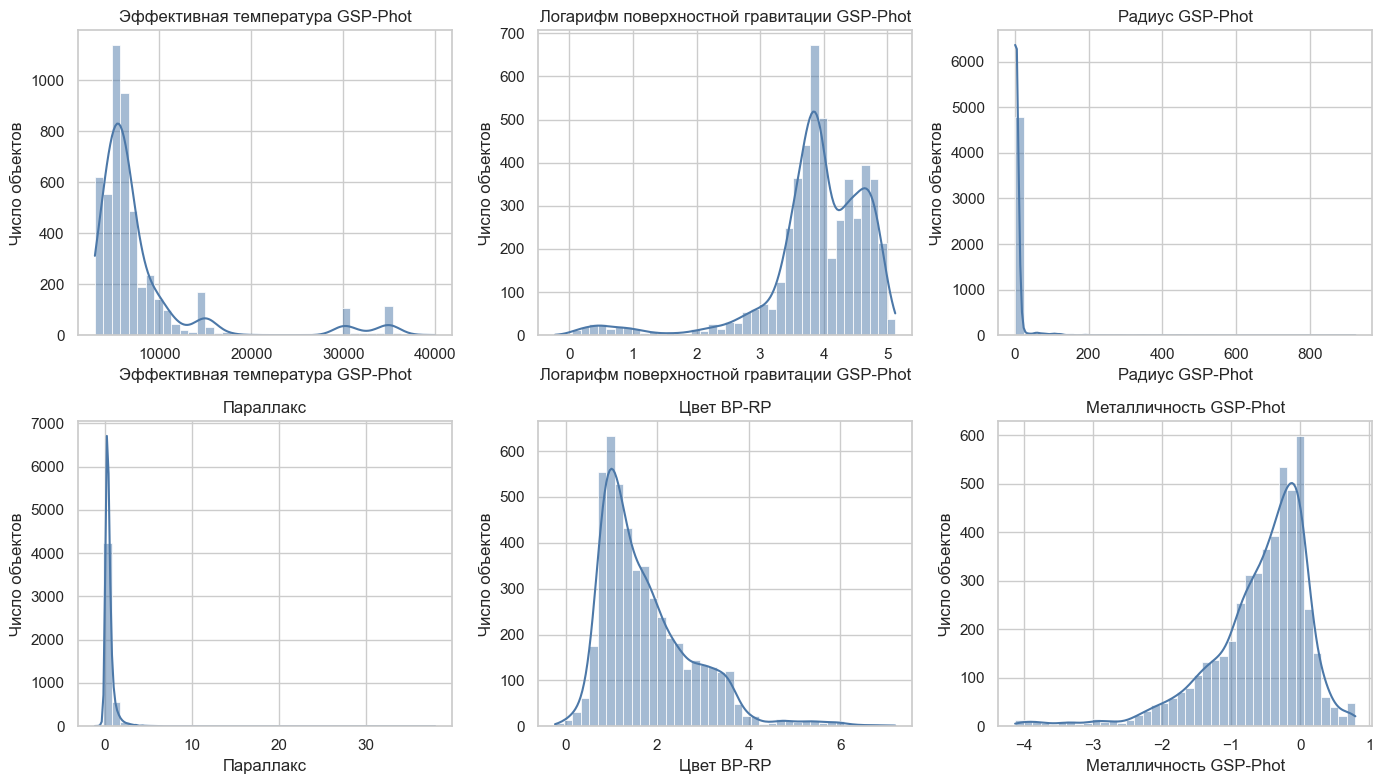

In [7]:
# Гистограммы основных признаков router-выборки.
plot_columns = [
    name
    for name in ("teff_gspphot", "logg_gspphot", "radius_gspphot", "parallax", "bp_rp", "mh_gspphot")
    if name in router_df.columns
]
plot_df = router_df.loc[:, plot_columns].dropna().head(PLOT_SAMPLE_SIZE)
axis_labels = {
    "teff_gspphot": "Эффективная температура GSP-Phot",
    "logg_gspphot": "Логарифм поверхностной гравитации GSP-Phot",
    "radius_gspphot": "Радиус GSP-Phot",
    "parallax": "Параллакс",
    "bp_rp": "Цвет BP-RP",
    "mh_gspphot": "Металличность GSP-Phot",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, column_name in zip(axes.flatten(), plot_columns, strict=False):
    sns.histplot(plot_df, x=column_name, bins=40, kde=True, ax=axis, color="#4C78A8")
    axis.set_title(axis_labels.get(column_name, column_name))
    axis.set_xlabel(axis_labels.get(column_name, column_name))
    axis.set_ylabel("Число объектов")

for axis in axes.flatten()[len(plot_columns):]:
    axis.set_visible(False)

plt.tight_layout()


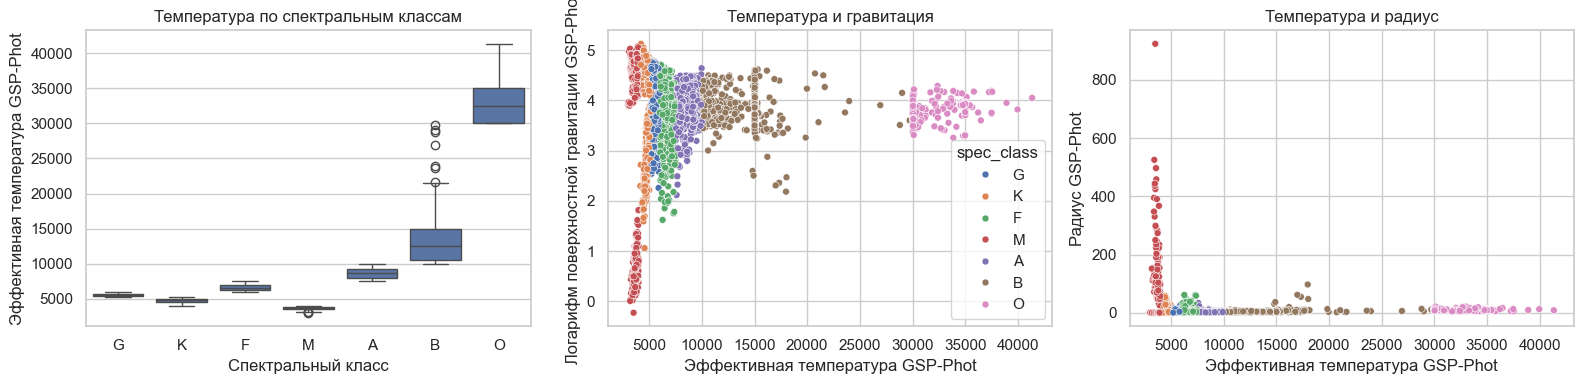

In [8]:
# Boxplot и scatter для визуальной разделимости coarse-задачи.
scatter_df = router_df.head(PLOT_SAMPLE_SIZE).copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=scatter_df, x="spec_class", y="teff_gspphot", ax=axes[0])
axes[0].set_title("Температура по спектральным классам")
axes[0].set_xlabel("Спектральный класс")
axes[0].set_ylabel("Эффективная температура GSP-Phot")

sns.scatterplot(
    data=scatter_df,
    x="teff_gspphot",
    y="logg_gspphot",
    hue="spec_class",
    ax=axes[1],
    s=25,
)
axes[1].set_title("Температура и гравитация")
axes[1].set_xlabel("Эффективная температура GSP-Phot")
axes[1].set_ylabel("Логарифм поверхностной гравитации GSP-Phot")

sns.scatterplot(
    data=scatter_df,
    x="teff_gspphot",
    y="radius_gspphot",
    hue="spec_class",
    ax=axes[2],
    s=25,
    legend=False,
)
axes[2].set_title("Температура и радиус")
axes[2].set_xlabel("Эффективная температура GSP-Phot")
axes[2].set_ylabel("Радиус GSP-Phot")

plt.tight_layout()


## Что смотреть в выводе

- Какие классы доминируют в источнике?
- Насколько чисто выглядят `teff/logg/radius` для coarse-задачи?
- Нет ли критичных пропусков или аномальных диапазонов?
- Можно ли переходить к обучению без дополнительной чистки источника?